Задача про выравнивание численности населения в нескольких городах с помощью образовательной миграции между ними (поступление студентов в вуз).

Ключевые особенности реализации:

Шумовая модель: Орнштейна-Уленбека для плавного исследования

Факторы среды:

Естественный прирост населения (0.8% в год)

Случайные бедствия (-5% населения с вероятностью 2%)

Ограничения емкости вузов

Архитектура сетей:

Актор с Softmax-нормализацией действий

Критик с раздельными ветвями для состояния и действия

Награда: Штраф за отклонение от среднего по городам

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import deque

In [2]:
# Параметры среды
NUM_CITIES = 5
INIT_POPULATION = torch.tensor([80000, 120000, 95000, 150000, 60000], dtype=torch.float32)
UNIVERSITY_CAPACITY = torch.tensor([5000, 8000, 6000, 10000, 4000], dtype=torch.float32)
MIGRATION_RATE = 0.15
NOISE_STD = 0.1
GROWTH_RATE = 0.008
EPISODES = 5000

In [3]:
# Параметры DDPG
ACTOR_LR = 0.0001
CRITIC_LR = 0.001
GAMMA = 0.99
TAU = 0.005
BUFFER_SIZE = 100000
BATCH_SIZE = 64

In [4]:
class Actor(nn.Module):
    def __init__(self):
        super(Actor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(NUM_CITIES, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, NUM_CITIES),
            nn.Softmax(dim=-1)
        )

    def forward(self, state):
        return self.net(state)

In [5]:
class Critic(nn.Module):
    def __init__(self):
        super(Critic, self).__init__()
        self.state_net = nn.Sequential(
            nn.Linear(NUM_CITIES, 128),
            nn.ReLU()
        )
        self.action_net = nn.Sequential(
            nn.Linear(NUM_CITIES, 128),
            nn.ReLU()
        )
        self.final = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, state, action):
        state_out = self.state_net(state)
        action_out = self.action_net(action)
        return self.final(torch.cat([state_out, action_out], dim=-1))

In [6]:
class ReplayBuffer:
    def __init__(self):
        self.buffer = deque(maxlen=BUFFER_SIZE)

    def add(self, state, action, reward, next_state):
        self.buffer.append((state, action, reward, next_state))

    def sample(self):
        return random.sample(self.buffer, BATCH_SIZE)

In [7]:
class OUNoise:
    def __init__(self, size, theta=0.15, dt=1e-2):
        self.theta = theta
        self.mu = 0.0
        self.dt = dt
        self.size = size
        self.reset()

    def reset(self):
        self.state = np.ones(self.size) * self.mu

    def sample(self):
        dx = self.theta * (self.mu - self.state) * self.dt
        self.state += dx + np.random.normal(scale=0.2, size=self.size)
        return torch.tensor(self.state, dtype=torch.float32)

class DDPGAgent:
    def __init__(self):
        self.actor = Actor()
        self.actor_target = Actor()
        self.critic = Critic()
        self.critic_target = Critic()

        self.actor_optim = optim.Adam(self.actor.parameters(), lr=ACTOR_LR)
        self.critic_optim = optim.Adam(self.critic.parameters(), lr=CRITIC_LR)

        self.buffer = ReplayBuffer()
        self.noise = OUNoise(NUM_CITIES)

        # Инициализация целевых сетей
        self.actor_target.load_state_dict(self.actor.state_dict())
        self.critic_target.load_state_dict(self.critic.state_dict())

    def get_action(self, state, add_noise=True):
        with torch.no_grad():
            action = self.actor(state)
            if add_noise:
                noise = self.noise.sample()
                action = torch.clamp(action + noise, 0, 1)
            return action

    def update(self):
        if len(self.buffer.buffer) < BATCH_SIZE:
            return

        samples = self.buffer.sample()
        states, actions, rewards, next_states = zip(*samples)

        states = torch.stack(states)
        actions = torch.stack(actions)
        rewards = torch.tensor(rewards, dtype=torch.float32)
        next_states = torch.stack(next_states)

        # Обновление критика
        with torch.no_grad():
            target_actions = self.actor_target(next_states)
            target_q = self.critic_target(next_states, target_actions)
            target_q = rewards + GAMMA * target_q.squeeze()

        current_q = self.critic(states, actions).squeeze()
        critic_loss = nn.MSELoss()(current_q, target_q)

        self.critic_optim.zero_grad()
        critic_loss.backward()
        self.critic_optim.step()

        # Обновление актора
        actor_loss = -self.critic(states, self.actor(states)).mean()

        self.actor_optim.zero_grad()
        actor_loss.backward()
        self.actor_optim.step()

        # Мягкое обновление целевых сетей
        for param, target_param in zip(self.actor.parameters(), self.actor_target.parameters()):
            target_param.data.copy_(TAU * param.data + (1 - TAU) * target_param.data)

        for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
            target_param.data.copy_(TAU * param.data + (1 - TAU) * target_param.data)

        return critic_loss.item()

In [8]:
# Среда моделирования
class CityEnvironment:
    def __init__(self):
        self.population = INIT_POPULATION.clone()
        self.year = 0

    def step(self, action):
        # Миграция студентов
        migrations = torch.min(action * UNIVERSITY_CAPACITY, UNIVERSITY_CAPACITY)
        net_migration = torch.sum(migrations) * MIGRATION_RATE

        # Естественный прирост и случайные события
        growth = self.population * GROWTH_RATE
        disaster = torch.where(torch.rand(NUM_CITIES) < 0.02, -0.05 * self.population, 0)

        new_population = self.population + growth + migrations - net_migration + disaster
        self.population = torch.clamp(new_population, min=10000)

        # Награда за равномерность распределения
        target = torch.mean(self.population)
        reward = -torch.sum(torch.abs(self.population - target)).item()

        self.year += 1
        done = self.year >= 30

        return self.population.clone(), reward, done

    def reset(self):
        self.population = INIT_POPULATION.clone()
        self.year = 0
        return self.population

In [9]:
# Обучение агента
agent = DDPGAgent()
env = CityEnvironment()
rewards = []
critic_losses = []

for episode in range(EPISODES):
    state = env.reset()
    episode_reward = 0

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)
        agent.buffer.add(state, action, reward, next_state)

        loss = agent.update()
        if loss is not None:
            critic_losses.append(loss)

        episode_reward += reward
        state = next_state

        if done:
            break

    rewards.append(episode_reward)

    if episode % 100 == 0:
        print(f"Episode {episode}, Reward: {episode_reward:.1f}")

Episode 0, Reward: -8097628.5
Episode 100, Reward: -7019136.4
Episode 200, Reward: -13092753.1
Episode 300, Reward: -10391152.6
Episode 400, Reward: -11549834.4
Episode 500, Reward: -9952840.4
Episode 600, Reward: -9136193.8
Episode 700, Reward: -3730066.9
Episode 800, Reward: -3569788.0
Episode 900, Reward: -15297641.9
Episode 1000, Reward: -7251108.8
Episode 1100, Reward: -9103798.7
Episode 1200, Reward: -6696821.4
Episode 1300, Reward: -3689153.0
Episode 1400, Reward: -3030301.1
Episode 1500, Reward: -9263055.5
Episode 1600, Reward: -5000691.7
Episode 1700, Reward: -9274605.4
Episode 1800, Reward: -6092613.9
Episode 1900, Reward: -10852235.6
Episode 2000, Reward: -8950977.7
Episode 2100, Reward: -11418168.1
Episode 2200, Reward: -12292023.1
Episode 2300, Reward: -4287963.3
Episode 2400, Reward: -12501860.3
Episode 2500, Reward: -8256056.9
Episode 2600, Reward: -10860428.7
Episode 2700, Reward: -10402159.1
Episode 2800, Reward: -13117256.6
Episode 2900, Reward: -13175456.1
Episode 30

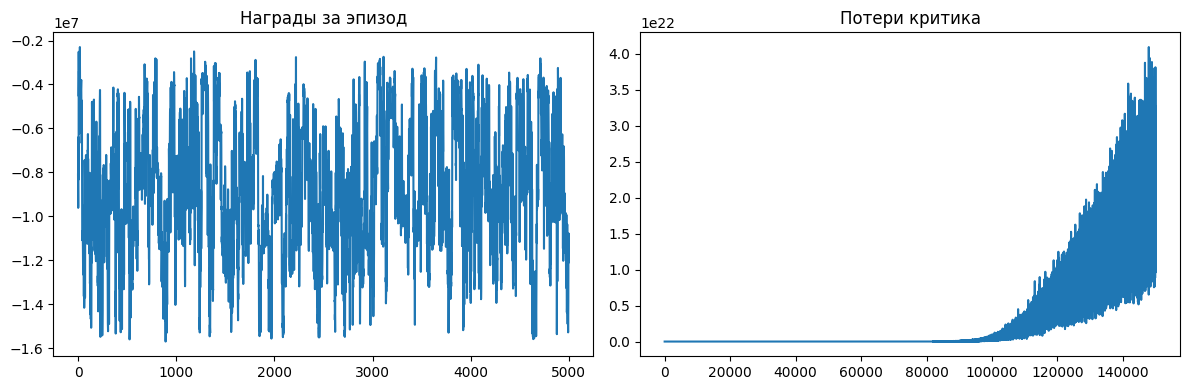

In [10]:
# Визуализация
plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.plot(rewards)
plt.title("Награды за эпизод")
plt.subplot(122)
plt.plot(critic_losses)
plt.title("Потери критика")
plt.tight_layout()
plt.show()


In [11]:
# Тестирование финальной политики
test_env = CityEnvironment()
states = [test_env.population.numpy().copy()]

for _ in range(30):
    action = agent.get_action(test_env.population, add_noise=False)
    next_state, _, _ = test_env.step(action)
    states.append(next_state.numpy().copy())


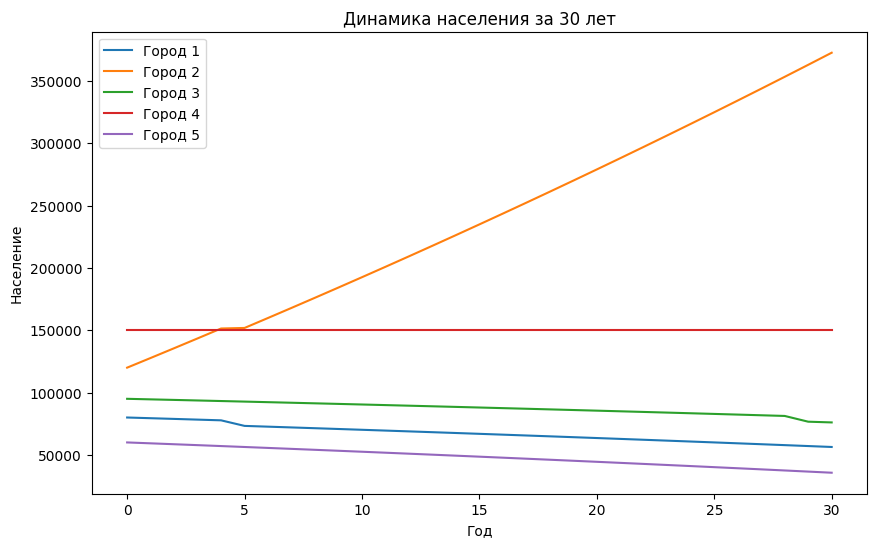

In [12]:
plt.figure(figsize=(10, 6))
for i in range(NUM_CITIES):
    plt.plot([s[i] for s in states], label=f"Город {i+1}")
plt.title("Динамика населения за 30 лет")
plt.xlabel("Год")
plt.ylabel("Население")
plt.legend()
plt.show()